In [97]:
import os
import json
import random
from pathlib import Path
from prompt_pool import PROMPT_POOL


In [98]:
# =========================================================
# 全局参数
# =========================================================

RANDOM_SEED = 42
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

random.seed(RANDOM_SEED)

# =========================================================
# 路径配置：把这里改成你自己的真实路径
# 所有图片都应该已经是 400x400 的处理后版本
# =========================================================

PATHS = {
    "reflection": {
        "input_dir": Path(r"H:\aai\dtst\processed\trainigPairs\B"),
        "target_dir": Path(r"H:\aai\dtst\processed\trainigPairs\A"),
    },

    "deblur": {
        "input_dir": Path(r"H:\aai\dtst\processed\blur\dirty"),
        "target_dir": Path(r"H:\aai\dtst\processed\blur\clear"),
    },

    "denoise": {
        "input_dir": Path(r"H:\aai\dtst\processed\noise"),
        "target_dir": Path(r"H:\aai\dtst\processed\noise"),
    },

    "derain_raindrop": {
        "input_dir": Path(r"H:\aai\dtst\processed\rain\raindrop"),
        "target_dir": Path(r"H:\aai\dtst\processed\rain\gt"),
    },

    "derain_streak": {
        "input_dir": Path(r"H:\aai\dtst\processed\rain\rainstreak"),
        "target_dir": Path(r"H:\aai\dtst\processed\rain\gt"),
    },

    "derain_both": {
        "input_dir": Path(r"H:\aai\dtst\processed\rain\rainstreak_raindrop"),
        "target_dir": Path(r"H:\aai\dtst\processed\rain\gt"),
    }
}

In [99]:
# =========================================================
# 工具函数
# =========================================================

def is_image_file(filename):
    return filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))

def get_random_prompt(task):
    return random.choice(PROMPT_POOL[task])

def split_dataset(samples, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8, "Ratios must sum to 1."

    random.shuffle(samples)

    n = len(samples)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_samples = samples[:train_end]
    val_samples = samples[train_end:val_end]
    test_samples = samples[val_end:]

    return train_samples, val_samples, test_samples

def save_json(data, save_path):
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

# =========================================================
# 通用的“同名配对”函数
# 适用于：
# input/1-1.jpeg <-> target/1-1.jpeg
# input/0001.png <-> target/0001.png
# =========================================================

def build_same_name_pairs(input_dir, target_dir, task):
    samples = []

    print(f"\n[INFO] Building task: {task}")
    print("Input dir :", input_dir)
    print("Target dir:", target_dir)

    if not input_dir.exists():
        print(f"[ERROR] Input dir does not exist: {input_dir}")
        return []

    if not target_dir.exists():
        print(f"[ERROR] Target dir does not exist: {target_dir}")
        return []

    input_files = sorted(os.listdir(input_dir))
    matched_count = 0
    missing_count = 0
    skipped_non_image = 0

    for fname in input_files:
        if not is_image_file(fname):
            skipped_non_image += 1
            continue

        input_path = input_dir / fname
        target_path = target_dir / fname

        if target_path.exists():
            samples.append({
                "input": str(input_path),
                "target": str(target_path),
                "task": task,
                "prompt": get_random_prompt(task)
            })
            matched_count += 1
        else:
            print(f"[WARNING] Missing target for: {fname}")
            missing_count += 1

    print(f"[INFO] Task={task}, matched={matched_count}, missing={missing_count}, skipped_non_image={skipped_non_image}")
    return samples




In [100]:
# =========================================================
# 各任务构建函数
# 如果你的所有任务都是“同名配对”，其实都可以共用
# =========================================================

def build_reflection():
    cfg = PATHS["reflection"]
    return build_same_name_pairs(cfg["input_dir"], cfg["target_dir"], "reflection")

def build_deblur():
    cfg = PATHS["deblur"]
    return build_same_name_pairs(cfg["input_dir"], cfg["target_dir"], "deblur")

def build_denoise():

    folder = Path(r"H:\aai\dtst\processed\noise")

    samples = []

    real_map = {}
    mean_map = {}

    print("Scanning denoise folder:", folder)

    for fname in os.listdir(folder):

        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        if fname.endswith("_real.jpeg"):
            key = fname.replace("_real.jpeg", "")
            real_map[key] = fname

        elif fname.endswith("_mean.jpeg"):
            key = fname.replace("_mean.jpeg", "")
            mean_map[key] = fname

    matched = 0
    missing = 0

    for key in real_map:

        if key in mean_map:

            input_path = folder / real_map[key]
            target_path = folder / mean_map[key]

            samples.append({
                "input": str(input_path),
                "target": str(target_path),
                "task": "denoise",
                "prompt": "remove noise"
            })

            matched += 1

        else:
            print("Missing clean image for:", real_map[key])
            missing += 1

    print("Denoise matched pairs:", matched)
    print("Missing pairs:", missing)

    return samples

def build_derain_raindrop():
    cfg = PATHS["derain_raindrop"]
    return build_same_name_pairs(cfg["input_dir"], cfg["target_dir"], "derain_raindrop")

def build_derain_streak():
    cfg = PATHS["derain_streak"]
    return build_same_name_pairs(cfg["input_dir"], cfg["target_dir"], "derain_streak")

def build_derain_both():
    cfg = PATHS["derain_both"]
    return build_same_name_pairs(cfg["input_dir"], cfg["target_dir"], "derain_both")



In [101]:
# =========================================================
# 主函数
# =========================================================

def main():
    all_samples = []

    # 逐个任务构建
    all_samples += build_reflection()
    all_samples += build_deblur()
    all_samples += build_denoise()
    all_samples += build_derain_raindrop()
    all_samples += build_derain_streak()
    all_samples += build_derain_both()

    print("\n[INFO] Total samples collected:", len(all_samples))

    if len(all_samples) == 0:
        print("[ERROR] No samples collected. Please check your paths.")
        return

    # 划分数据集
    train_samples, val_samples, test_samples = split_dataset(
        all_samples,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
        test_ratio=TEST_RATIO
    )

    print("[INFO] Train samples:", len(train_samples))
    print("[INFO] Val samples  :", len(val_samples))
    print("[INFO] Test samples :", len(test_samples))

    # 保存
    save_json(train_samples, "train_metadata.json")
    save_json(val_samples, "val_metadata.json")
    save_json(test_samples, "test_metadata.json")

    print("\n[INFO] Metadata files generated successfully.")
    print("[INFO] Saved files:")
    print(" - train_metadata.json")
    print(" - val_metadata.json")
    print(" - test_metadata.json")

if __name__ == "__main__":
    main()



[INFO] Building task: reflection
Input dir : H:\aai\dtst\processed\trainigPairs\B
Target dir: H:\aai\dtst\processed\trainigPairs\A
[INFO] Task=reflection, matched=1018, missing=0, skipped_non_image=0

[INFO] Building task: deblur
Input dir : H:\aai\dtst\processed\blur\dirty
Target dir: H:\aai\dtst\processed\blur\clear
[INFO] Task=deblur, matched=1029, missing=0, skipped_non_image=0
Scanning denoise folder: H:\aai\dtst\processed\noise
Denoise matched pairs: 0
Missing pairs: 0

[INFO] Building task: derain_raindrop
Input dir : H:\aai\dtst\processed\rain\raindrop
Target dir: H:\aai\dtst\processed\rain\gt
[INFO] Task=derain_raindrop, matched=98, missing=0, skipped_non_image=0

[INFO] Building task: derain_streak
Input dir : H:\aai\dtst\processed\rain\rainstreak
Target dir: H:\aai\dtst\processed\rain\gt
[WARNING] Missing target for: IMG_7435.png
[INFO] Task=derain_streak, matched=97, missing=1, skipped_non_image=0

[INFO] Building task: derain_both
Input dir : H:\aai\dtst\processed\rain\ra

In [102]:
from pathlib import Path
import os

folder = Path(r"H:\aai\dtst\processed\noise")

real_count = 0
mean_count = 0

for f in os.listdir(folder):

    if f.endswith("_real.JPG"):
        real_count += 1

    if f.endswith("_mean.JPG"):
        mean_count += 1

print("Real images:", real_count)
print("Mean images:", mean_count)

Real images: 100
Mean images: 100


In [103]:
from pathlib import Path
import os

folder = Path(r"H:\aai\dtst\processed\noise")

missing = 0
matched = 0

for f in os.listdir(folder):

    if f.endswith("_real.JPG"):

        key = f.replace("_real.JPG","")
        target = folder / f"{key}_mean.JPG"

        if target.exists():
            matched += 1
        else:
            print("Missing clean image:", f)
            missing += 1

print("Matched pairs:", matched)
print("Missing pairs:", missing)

Matched pairs: 100
Missing pairs: 0


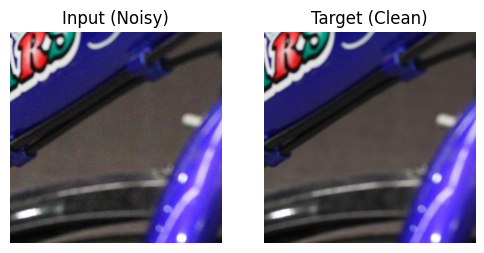

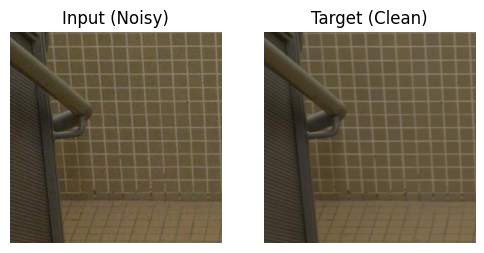

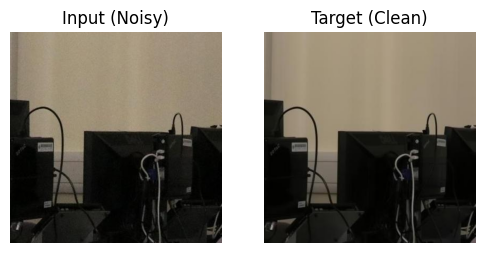

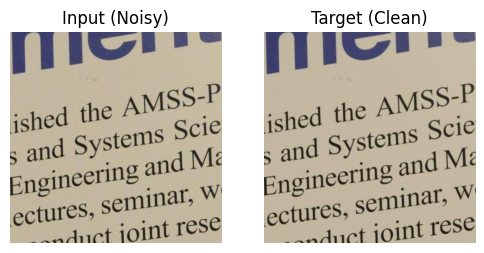

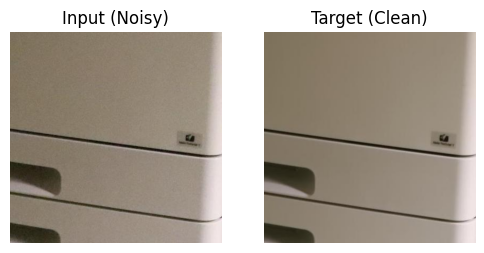

In [104]:
import random
from PIL import Image
import matplotlib.pyplot as plt

pairs = []

for f in os.listdir(folder):

    if f.endswith("_real.JPG"):
        key = f.replace("_real.JPG","")
        pairs.append((f, f"{key}_mean.JPG"))

sample_pairs = random.sample(pairs, 5)

for noisy, clean in sample_pairs:

    img1 = Image.open(folder/noisy)
    img2 = Image.open(folder/clean)

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.title("Input (Noisy)")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.title("Target (Clean)")
    plt.axis("off")

    plt.show()

In [105]:
import json

with open("train_metadata.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(len(data))          # 总样本数
for sample in data[:50]:
    print("INPUT :", sample["input"])
    print("TARGET:", sample["target"])
    print("TASK  :", sample["task"])
    print("PROMPT:", sample["prompt"])
    print("-"*50)

1872
INPUT : H:\aai\dtst\processed\blur\dirty\000977.png
TARGET: H:\aai\dtst\processed\blur\clear\000977.png
TASK  : deblur
PROMPT: make the image sharp
--------------------------------------------------
INPUT : H:\aai\dtst\processed\blur\dirty\002817.png
TARGET: H:\aai\dtst\processed\blur\clear\002817.png
TASK  : deblur
PROMPT: deblur the image
--------------------------------------------------
INPUT : H:\aai\dtst\processed\trainigPairs\B\62-5.jpeg
TARGET: H:\aai\dtst\processed\trainigPairs\A\62-5.jpeg
TASK  : reflection
PROMPT: clean reflection from image
--------------------------------------------------
INPUT : H:\aai\dtst\processed\trainigPairs\B\104-6.jpeg
TARGET: H:\aai\dtst\processed\trainigPairs\A\104-6.jpeg
TASK  : reflection
PROMPT: eliminate glass reflection
--------------------------------------------------
INPUT : H:\aai\dtst\processed\rain\rainstreak_raindrop\139.png
TARGET: H:\aai\dtst\processed\rain\gt\139.png
TASK  : derain_both
PROMPT: clear rain and droplets
-------